In [36]:
import pandas as pd
import numpy as np
import FIRM.base.fuzzy_data as fuzzy_data
from FIRM.methods.AARFI import AARFI, AARFI_F
def process_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    - Integer dtypes -> float64
    - For object/string/categorical columns:
        * If unique non-null values <= 15: keep as object
        * If unique non-null values > 15: keep top 15, others -> "Unknown"
    - Other dtypes left unchanged
    """
    out = df.copy()

    for col in out.columns:
        s = out[col]

        # 1) Integers -> float64
        if pd.api.types.is_integer_dtype(s):
            out[col] = s.astype("float64")
            continue

        # 2) Non-numeric categoricals/strings
        is_cat_like = (
            pd.api.types.is_object_dtype(s)
            or isinstance(s.dtype, pd.CategoricalDtype)
            or pd.api.types.is_string_dtype(s)
        )
        if is_cat_like:
            n_unique = s.nunique(dropna=True)
            if n_unique > 10:
                top15 = s.value_counts(dropna=True).index[:10]
                out[col] = s.where(s.isna() | s.isin(top15), "Unknown").astype("object")
            else:
                out[col] = s.astype("object")

    return out

In [37]:
df = process_df(pd.read_csv("../assets/iris.csv"))
dataset = df.copy()
# find integer columns and convert them to float
int_cols = dataset.select_dtypes(include=['int']).columns
dataset[int_cols] = dataset[int_cols].astype(float)
fuzzy_dataset = fuzzy_data.FuzzyDataQuantiles('symmetric', dataset, 3, ['L', 'M', 'H'])

In [38]:
I = lambda x, y: 1 - x + x * (y**0.01)
T = lambda x, y: np.maximum(x + y - 1, 0)
F = lambda x, y: x * (y ** 0.01)
rules, measures = AARFI_F(dataset, fuzzy_dataset, F=F,T=T,I=I, min_cov=0.0, min_supp=0.0, min_conf=0.0, max_feat=3,verbose=True)
measures

[INFO] AARFI_F (min_cov=0.000, min_supp=0.000, min_conf=0.000, max_feat=3)
[INFO] Starting Apriori (min_cov=0.0000, max_feat=3)...
[INFO] Precomputing singleton memberships for 150 rows and 5 features...
[INFO] Cached 15 singleton membership vectors.
[INFO] Generated 15 fuzzy 1-itemsets across 5 features (15 total labels).
[INFO] Evaluating 15 candidate itemsets (min_cov=0.0000)...
[INFO] Selected 15 frequent itemsets (100.0% pass rate).
[INFO] Level-1: 15 frequent itemsets.
[INFO] ---- Level 2 ----
[INFO] Joined 15 -> 90 candidates for next level.
[INFO] Apriori pruning: kept 90 / 90 (dropped 0).
[INFO] Evaluating 90 candidate itemsets (min_cov=0.0000)...
[INFO] Selected 90 frequent itemsets (100.0% pass rate).
[INFO] Level-2 frequent itemsets: 90
[INFO] ---- Level 3 ----
[INFO] Joined 90 -> 270 candidates for next level.
[INFO] Apriori pruning: kept 270 / 270 (dropped 0).
[INFO] Evaluating 270 candidate itemsets (min_cov=0.0000)...
[INFO] Selected 270 frequent itemsets (100.0% pass r

,rule,coverage,support,confidence,lrule,n_antecedents
0,IF ( PetalLength IS L AND PetalWidth IS L ) TH...,0.322909,0.322909,1.0,"((2, 0), (3, 0), (4, 0))",2
1,IF ( SepalLength IS L AND SepalWidth IS H ) TH...,0.201905,0.201905,1.0,"((0, 0), (1, 2), (4, 0))",2
2,IF ( SepalLength IS L AND SepalWidth IS H AND ...,0.199481,0.199481,1.0,"((0, 0), (1, 2), (2, 0), (4, 0))",3
3,IF ( SepalLength IS L AND SepalWidth IS H AND ...,0.193905,0.193905,1.0,"((0, 0), (1, 2), (3, 0), (4, 0))",3
4,IF ( SepalWidth IS L AND PetalLength IS M AND ...,0.112646,0.112646,1.0,"((1, 0), (2, 1), (3, 1), (4, 1))",3
...,...,...,...,...,...,...
2605,IF ( PetalLength IS L AND PetalWidth IS L AND ...,0.000000,0.000000,0.0,"((2, 0), (3, 0), (4, 2), (0, 1))",3
2606,IF ( PetalLength IS L AND PetalWidth IS L AND ...,0.000000,0.000000,0.0,"((2, 0), (3, 0), (4, 2), (0, 2))",3
2607,IF ( PetalLength IS L AND PetalWidth IS L AND ...,0.000000,0.000000,0.0,"((2, 0), (3, 0), (4, 2), (1, 0))",3
2608,IF ( PetalLength IS L AND PetalWidth IS L AND ...,0.000000,0.000000,0.0,"((2, 0), (3, 0), (4, 2), (1, 1))",3


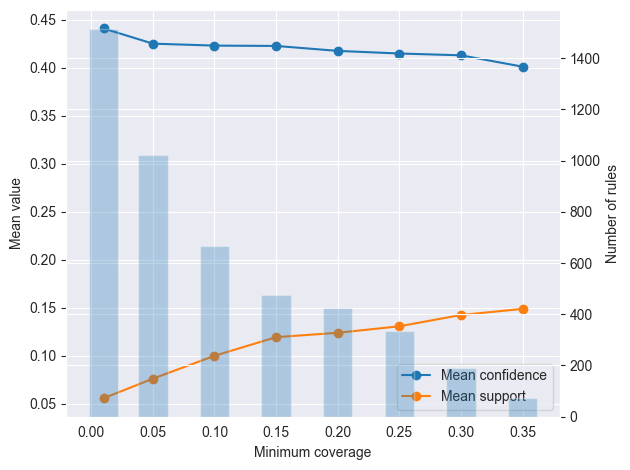

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# measures must have columns: 'coverage', 'support', 'confidence'
min_cov_values = [0.01,0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35]  # adjust as you like

rows = []
for mc in min_cov_values:
    df = measures[measures["coverage"] >= mc]
    rows.append({
        "min_cov": mc,
        "mean_confidence": df["confidence"].mean() if not df.empty else np.nan,
        "mean_support": df["support"].mean() if not df.empty else np.nan,
        "n_rules": len(df),
    })

summary = pd.DataFrame(rows)

x = summary["min_cov"].to_numpy()
y_conf = summary["mean_confidence"].to_numpy()
y_supp = summary["mean_support"].to_numpy()
y_count = summary["n_rules"].to_numpy()

fig, ax1 = plt.subplots()

ax1.plot(x, y_conf, marker="o", label="Mean confidence")
ax1.plot(x, y_supp, marker="o", label="Mean support")
ax1.set_xlabel("Minimum coverage")
ax1.set_ylabel("Mean value")
ax1.grid(True, which="both", axis="both")
ax1.legend(loc="best")

ax2 = ax1.twinx()
width = (np.min(np.diff(np.sort(x))) * 0.6) if len(x) > 1 else 0.05
ax2.bar(x, y_count, width=width, alpha=0.3)
ax2.set_ylabel("Number of rules")

plt.tight_layout()
plt.show()


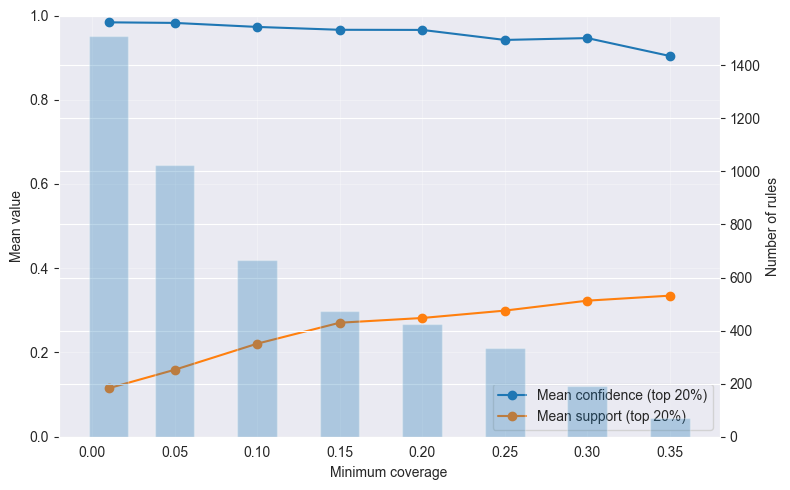

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# measures must have columns: 'coverage', 'support', 'confidence'
min_cov_values = [0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35]  # adjust as you like

rows = []
for mc in min_cov_values:
    df = measures[measures["coverage"] >= mc]
    if df.empty:
        rows.append({
            "min_cov": mc,
            "mean_confidence_top20": np.nan,
            "mean_support_top20": np.nan,
            "n_rules": 0,
        })
    else:
        n_top = max(1, int(np.ceil(0.20 * len(df))))
        df_top = df.sort_values("confidence", ascending=False).head(n_top)
        rows.append({
            "min_cov": mc,
            "mean_confidence_top20": df_top["confidence"].mean(),
            "mean_support_top20": df_top["support"].mean(),
            "n_rules": len(df),
        })

summary = pd.DataFrame(rows).sort_values("min_cov").reset_index(drop=True)

x = summary["min_cov"].to_numpy()
y_conf = summary["mean_confidence_top20"].to_numpy()
y_supp = summary["mean_support_top20"].to_numpy()
y_count = summary["n_rules"].to_numpy()

fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(x, y_conf, marker="o", label="Mean confidence (top 20%)")
ax1.plot(x, y_supp, marker="o", label="Mean support (top 20%)")
ax1.set_xlabel("Minimum coverage")
ax1.set_ylabel("Mean value")
ax1.set_ylim(0, 1)
ax1.grid(True, which="both", axis="both", alpha=0.3)
ax1.legend(loc="best")

ax2 = ax1.twinx()
width = (np.min(np.diff(np.sort(x))) * 0.6) if len(x) > 1 else 0.05
ax2.bar(x, y_count, width=width, alpha=0.3)
ax2.set_ylabel("Number of rules")

plt.tight_layout()
plt.show()